# "Machine Learning \& Deep Learning Applications in Modern Power Systems"
## Department of Electrical Engineering - PMEC, Berhampur
### Instructor: Dr. Suryalok Dash 

# Day 2: Exercise Notebook
**Task:** Complete the missing code sections marked with `### YOUR CODE HERE ###`.

In [2]:
import pandas as pd
import numpy as np

# We provide a simulated microgrid dataset
microgrid_data = {
    'Timestamp': ['08:00', '09:00', '10:00', '11:00', '12:00', '13:00', '14:00'],
    'Solar_kW': [5.2, 12.5, 20.1, np.nan, 28.5, 30.0, 27.2],
    'Load_kW': [15.0, 18.2, np.nan, 22.5, 24.0, 23.5, 21.0],
    'Battery_SoC_%': [80, 75, 70, 68, 72, 85, 90]
}
df_mg = pd.DataFrame(microgrid_data)

# Task 1: Print the first 4 rows of the DataFrame
print(df_mg.head(4))

# Task 2: Print the data types of each column
print("\nData Types:")
print(df_mg.dtypes)

# Task 3: Print the summary statistics (mean, std, min, max) of the DataFrame
print("\nSummary Statistics:")
print(df_mg.describe())

  Timestamp  Solar_kW  Load_kW  Battery_SoC_%
0     08:00       5.2     15.0             80
1     09:00      12.5     18.2             75
2     10:00      20.1      NaN             70
3     11:00       NaN     22.5             68

Data Types:
Timestamp            str
Solar_kW         float64
Load_kW          float64
Battery_SoC_%      int64
dtype: object

Summary Statistics:
        Solar_kW    Load_kW  Battery_SoC_%
count   6.000000   6.000000       7.000000
mean   20.583333  20.700000      77.142857
std     9.973448   3.487119       8.173709
min     5.200000  15.000000      68.000000
25%    14.400000  18.900000      71.000000
50%    23.650000  21.750000      75.000000
75%    28.175000  23.250000      82.500000
max    30.000000  24.000000      90.000000


In [3]:
# Task 4: Count the total number of missing values in each column
missing_counts = df_mg.isnull().sum()
print("Missing Counts:\n", missing_counts)

# Task 5: Fill the missing value in 'Solar_kW' with the number 25.0
df_mg['Solar_kW'] = df_mg['Solar_kW'].fillna(25.0)

# Task 6: Fill the missing value in 'Load_kW' using the mean of the 'Load_kW' column
df_mg['Load_kW'] = df_mg['Load_kW'].fillna(df_mg['Load_kW'].mean())
print("\nCleaned DataFrame:\n", df_mg)

Missing Counts:
 Timestamp        0
Solar_kW         1
Load_kW          1
Battery_SoC_%    0
dtype: int64

Cleaned DataFrame:
   Timestamp  Solar_kW  Load_kW  Battery_SoC_%
0     08:00       5.2     15.0             80
1     09:00      12.5     18.2             75
2     10:00      20.1     20.7             70
3     11:00      25.0     22.5             68
4     12:00      28.5     24.0             72
5     13:00      30.0     23.5             85
6     14:00      27.2     21.0             90


In [4]:
# Task 7: Filter the DataFrame to show only rows where Solar generation is greater than 20 kW
high_solar_df = df_mg[df_mg['Solar_kW'] > 20]
print("High Solar Generation:\n", high_solar_df)

# Task 8: Filter the DataFrame to show only rows where Battery SoC is less than or equal to 75%
low_battery_df = df_mg[df_mg['Battery_SoC_%'] <= 75]

# Task 9: Extract just the 'Timestamp' and 'Load_kW' columns into a new DataFrame
load_profile_df = df_mg[['Timestamp', 'Load_kW']]
print("\nLoad Profile:\n", load_profile_df)

High Solar Generation:
   Timestamp  Solar_kW  Load_kW  Battery_SoC_%
2     10:00      20.1     20.7             70
3     11:00      25.0     22.5             68
4     12:00      28.5     24.0             72
5     13:00      30.0     23.5             85
6     14:00      27.2     21.0             90

Load Profile:
   Timestamp  Load_kW
0     08:00     15.0
1     09:00     18.2
2     10:00     20.7
3     11:00     22.5
4     12:00     24.0
5     13:00     23.5
6     14:00     21.0


In [5]:
# Task 10: Create a new column called 'Net_Load_kW' which is (Load_kW - Solar_kW)
df_mg['Net_Load_kW'] = df_mg['Load_kW'] - df_mg['Solar_kW']

# Task 11: Create a new column called 'Grid_Status' 
# Set it to "Exporting" if Net_Load_kW is negative, else "Importing"
# Hint: Use np.where(condition, value_if_true, value_if_false)
df_mg['Grid_Status'] = np.where(
    df_mg['Net_Load_kW'] < 0, "Exporting","Importing")
# Task 12: Calculate the total load energy consumed over these 7 hours (sum of Load_kW)
total_load_energy = df_mg['Load_kW'].sum()
print("Total Load Energy:", total_load_energy)
print("\nUpdated DataFrame:\n", df_mg)

Total Load Energy: 144.9

Updated DataFrame:
   Timestamp  Solar_kW  Load_kW  Battery_SoC_%  Net_Load_kW Grid_Status
0     08:00       5.2     15.0             80          9.8   Importing
1     09:00      12.5     18.2             75          5.7   Importing
2     10:00      20.1     20.7             70          0.6   Importing
3     11:00      25.0     22.5             68         -2.5   Exporting
4     12:00      28.5     24.0             72         -4.5   Exporting
5     13:00      30.0     23.5             85         -6.5   Exporting
6     14:00      27.2     21.0             90         -6.2   Exporting


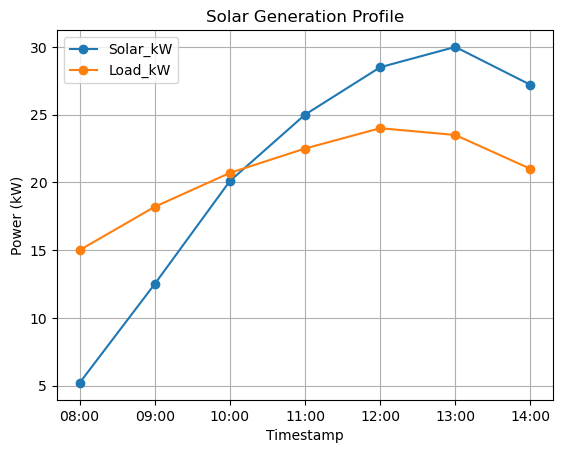

In [6]:
import matplotlib.pyplot as plt

# Task 13: Create a line plot of 'Timestamp' (x-axis) vs 'Solar_kW' (y-axis)
plt.plot(df_mg['Timestamp'], df_mg['Solar_kW'], marker='o', label='Solar_kW')

# Task 14: Add a title "Solar Generation Profile" and labels for the X and Y axes
plt.title("Solar Generation Profile")
plt.xlabel("Timestamp")
plt.ylabel("Power (kW)")
# Task 15: Add a second line to the same plot showing 'Load_kW'. Add a legend and display the plot.
plt.plot(df_mg['Timestamp'], df_mg['Load_kW'], marker='o', label='Load_kW')
plt.legend()
plt.grid(True)
plt.show()